In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
import matplotlib.dates as mdates

In [2]:
# df = pd.read_csv('mta_1706.csv', on_bad_lines='skip')

files = [
    "mta_1706.csv",
    "mta_1708.csv",
    "mta_1710.csv",
    "mta_1712.csv"
]

df = pd.concat(
    [pd.read_csv(f, on_bad_lines='skip') for f in files],
    ignore_index=True
)

In [3]:
# ── 2. Clean ScheduledArrivalTime (fix 24:XX:XX → 00:XX:XX, drop >=25) ────
df['ScheduledArrivalTime'] = df['ScheduledArrivalTime'].astype(str).str.strip()

def validate_and_fix_time(time_str):
    if re.match(r'^\d{2}:\d{2}:\d{2}$', time_str):
        hour = int(time_str.split(':')[0])
        if hour == 24:
            return f"00:{time_str[3:]}"
        elif hour < 24:
            return time_str
    return None

df['valid_time'] = df['ScheduledArrivalTime'].apply(validate_and_fix_time)
df = df[df['valid_time'].notna()].copy()
df['ScheduledArrivalTime'] = df['valid_time']
df.drop('valid_time', axis=1, inplace=True)
print(f"After scheduled time filter: {len(df)} rows")

After scheduled time filter: 25331799 rows


In [4]:
# ── 3. Parse RecordedAtTime and ExpectedArrivalTime, drop NaT ──────────────
df['RecordedAtTime'] = pd.to_datetime(df['RecordedAtTime'], errors='coerce')
df['ExpectedArrivalTime'] = pd.to_datetime(df['ExpectedArrivalTime'], errors='coerce')
df = df[df['ExpectedArrivalTime'].notna() & df['RecordedAtTime'].notna()].copy()
print(f"After NaT drop: {len(df)} rows")

After NaT drop: 21914630 rows


In [5]:
# ── 4. Build Scheduled_dt by picking date closest to ExpectedArrivalTime ───
scheduled_time = pd.to_datetime(df['ScheduledArrivalTime'], format='%H:%M:%S').dt.time

expected_date_str = df['ExpectedArrivalTime'].dt.date.astype(str)
time_str = scheduled_time.astype(str)

candidate_same = pd.to_datetime(expected_date_str + ' ' + time_str)
candidate_prev = candidate_same - pd.Timedelta(days=1)

diff_same = (df['ExpectedArrivalTime'] - candidate_same).abs()
diff_prev = (df['ExpectedArrivalTime'] - candidate_prev).abs()

df['Scheduled_dt'] = candidate_same.where(diff_same <= diff_prev, candidate_prev)

In [6]:
# ── 5. Compute delay ───────────────────────────────────────────────────────
df['delay_minutes'] = (
    (df['ExpectedArrivalTime'] - df['Scheduled_dt']).dt.total_seconds() / 60
)

In [7]:
# ── 6. Sanity check ────────────────────────────────────────────────────────
print(f"\nFinal rows: {len(df)}")
print(f"\nDelay stats:")
print(df['delay_minutes'].describe())
print(f"\nSample:")
df[['RecordedAtTime', 'ExpectedArrivalTime', 'Scheduled_dt', 'delay_minutes']].head(10)


Final rows: 21914630

Delay stats:
count    2.191463e+07
mean     5.612012e+00
std      2.527030e+01
min     -2.980333e+02
25%     -1.333333e-01
50%      2.800000e+00
75%      7.866667e+00
max      1.439983e+03
Name: delay_minutes, dtype: float64

Sample:


,RecordedAtTime,ExpectedArrivalTime,Scheduled_dt,delay_minutes
0,2017-06-01 00:03:34,2017-06-01 00:03:59,2017-06-01 00:06:14,-2.250000
1,2017-06-01 00:03:43,2017-06-01 00:03:56,2017-05-31 23:58:02,5.900000
2,2017-06-01 00:03:49,2017-06-01 00:03:56,2017-06-01 00:00:53,3.050000
3,2017-06-01 00:03:31,2017-06-01 00:04:03,2017-06-01 00:03:00,1.050000
4,2017-06-01 00:03:22,2017-06-01 00:03:56,2017-05-31 23:59:38,4.300000
5,2017-06-01 00:03:40,2017-06-01 00:03:56,2017-06-01 00:02:35,1.350000
7,2017-06-01 00:03:29,2017-06-01 00:04:13,2017-05-31 23:58:47,5.433333
8,2017-06-01 00:03:27,2017-06-01 00:03:56,2017-06-01 00:00:00,3.933333
9,2017-06-01 00:03:51,2017-06-01 00:03:56,2017-06-01 00:01:14,2.700000
10,2017-06-01 00:03:48,2017-06-01 00:04:29,2017-05-31 23:48:35,15.900000


In [8]:
df.head()

,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime,Scheduled_dt,delay_minutes
0,2017-06-01 00:03:34,0.0,B8,4 AV/95 ST,40.616104,-74.031143,BROWNSVILLE ROCKAWAY AV,40.656048,-73.907379,NYCT_430,40.635170,-73.960803,FOSTER AV/E 18 ST,approaching,76.0,2017-06-01 00:03:59,00:06:14,2017-06-01 00:06:14,-2.25
1,2017-06-01 00:03:43,1.0,S61,ST GEORGE FERRY/S61 & S91,40.643169,-74.073494,S I MALL YUKON AV,40.575935,-74.167686,NYCT_8263,40.590802,-74.158340,MERRYMOUNT ST/TRAVIS AV,approaching,62.0,2017-06-01 00:03:56,23:58:02,2017-05-31 23:58:02,5.90
2,2017-06-01 00:03:49,0.0,Bx10,E 206 ST/BAINBRIDGE AV,40.875008,-73.880142,RIVERDALE 263 ST,40.912376,-73.902534,NYCT_4223,40.886010,-73.912647,HENRY HUDSON PKY E/W 235 ST,at stop,5.0,2017-06-01 00:03:56,00:00:53,2017-06-01 00:00:53,3.05
3,2017-06-01 00:03:31,0.0,Q5,TEARDROP/LAYOVER,40.701748,-73.802399,ROSEDALE LIRR STA via MERRICK,40.666012,-73.735939,NYCT_8422,40.668002,-73.729348,HOOK CREEK BL/SUNRISE HY,< 1 stop away,267.0,2017-06-01 00:04:03,00:03:00,2017-06-01 00:03:00,1.05
4,2017-06-01 00:03:22,1.0,Bx1,RIVERDALE AV/W 231 ST,40.881187,-73.909340,MOTT HAVEN 136 ST via CONCOURSE,40.809654,-73.928360,NYCT_4710,40.868134,-73.893032,GRAND CONCOURSE/E 196 ST,at stop,11.0,2017-06-01 00:03:56,23:59:38,2017-05-31 23:59:38,4.30


In [9]:
#Uncomment to save cleaned dataset (optional, as we export B41-only in the next step)
#output_path = "nyc_bus_cleaned.csv"

#df.to_csv(output_path, index=False)

#print(f"Saved cleaned df to {output_path}")

In [10]:
# Export B41-only dataset (June only)
df_b41_export = df[
    (df['PublishedLineName'] == 'B41')
    # & (df['Scheduled_dt'].dt.month == 6)
].copy()

df_b41_export.to_csv('nyc_b41_clean.csv', index=False)

print(f"Full cleaned dataset : {len(df):,} rows")
print(f"B41 only        : {len(df_b41_export):,} rows")
print(f"Size reduction       : {(1 - len(df_b41_export)/len(df))*100:.1f}%")

Full cleaned dataset : 21,914,630 rows
B41 only        : 348,053 rows
Size reduction       : 98.4%


In [13]:
# Aggregate average delay into 30-minute time buckets
df_b41_30m = (
    df_b41_export
    .set_index('Scheduled_dt')
    .resample('30min')['delay_minutes']
    .agg(
        avg_delay   = 'mean',
        median_delay= 'median',
        std_delay   = 'std',
        n_obs       = 'count'
    )
    .reset_index()
    .dropna(subset=['avg_delay'])
)

print(f"Rows in 30-min dataset: {len(df_b41_30m):,}")
print(df_b41_30m.head(10))

Rows in 30-min dataset: 5,762
         Scheduled_dt  avg_delay  median_delay   std_delay  n_obs
0 2017-05-31 23:30:00   9.940000      8.233333    4.720325      5
1 2017-06-01 00:00:00  73.181746      5.466667  312.375853     21
2 2017-06-01 00:30:00   2.930392      2.266667    4.206197     17
3 2017-06-01 01:00:00   0.852083      0.225000    1.984632      8
4 2017-06-01 01:30:00   1.695833      0.725000    3.001755      8
5 2017-06-01 02:00:00   0.837500      0.325000    3.044187     12
6 2017-06-01 02:30:00   0.938889      0.883333    0.933482      9
7 2017-06-01 03:00:00   0.878205      0.816667    1.556057     13
8 2017-06-01 03:30:00   5.915625      1.733333    8.023478     16
9 2017-06-01 04:00:00   0.831579     -0.200000    3.599108     19


In [18]:
df_b41_30m.to_csv('nyc_b41_30min.csv', index=False)
print("Saved: nyc_b41_30min.csv")

Saved: nyc_b41_30min.csv


## Finding Bus Routes and their stops

In [9]:
# ── Find all unique bus routes ─────────────────────────────────────────────
route_counts = df['PublishedLineName'].value_counts()

print(f"Total unique routes: {df['PublishedLineName'].nunique()}")
print(f"\nTop 20 routes by number of observations:")
print(route_counts.head(20))

Total unique routes: 242

Top 20 routes by number of observations:
PublishedLineName
B6          390695
B41         348053
Q58         314879
Q44-SBS     295141
B35         294302
Bx36        288273
M15-SBS     272554
M101        264437
B82         260572
Q27         259617
Bx15        253348
B15         250589
B46         246952
M4          222675
Bx19        221384
B38         219917
M15         215755
Bx12-SBS    213621
Bx9         211895
B46-SBS     197593
Name: count, dtype: int64


In [ ]:
# All stops for a specific route, e.g. B6
route_name = 'B6'
stops = (
    df[df['PublishedLineName'] == route_name]['NextStopPointName']
    .value_counts()
    .reset_index()
)
stops.columns = ['StopName', 'Observations']
print(f"\nStops for route {route_name} ({len(stops)} unique stops):")
print(stops)

Top 5 routes by number of observations:
['B6', 'B41', 'Q58', 'Q44-SBS', 'B35']

Stops for route B6 (119 unique stops):
                     StopName  Observations
0     GLENWOOD RD/NOSTRAND AV         15736
1        AV J/CONEY ISLAND AV         13716
2               AV H/UTICA AV         13113
3         HARWAY AV/BAY 37 ST         11949
4      ASHFORD ST/NEW LOTS AV         10886
..                        ...           ...
114    GLENWOOD RD/BEDFORD AV           694
115       GLENWOOD RD/E 34 ST           647
116      GLENWOOD RD/E 100 ST           485
117      FLATLANDS AV/E 76 ST           380
118  ROCKAWAY PKY/GLENWOOD RD           179

[119 rows x 2 columns]

Stops for route B41 (85 unique stops):
                   StopName  Observations
0     FLATBUSH AV/CHURCH AV         20504
1   FLATBUSH AV/NOSTRAND AV         18635
2   FLATBUSH AV/ATLANTIC AV         17681
3    TILLARY ST/CADMAN PZ W         17330
4     FLATBUSH AV/FOSTER AV         16220
..                      ...          

In [11]:
df_B6 = df[df['PublishedLineName'] == 'B6'].copy()

df_B6

,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime,Scheduled_dt,delay_minutes
20,2017-06-01 00:03:41,0.0,B6,HARWAY AV/BAY 37 ST,40.593510,-73.993996,EAST NY NEW LOTS STA,40.666420,-73.883385,NYCT_7158,40.645676,-73.901474,GLENWOOD RD/E 98 ST,at stop,4.0,2017-06-01 00:03:56,00:05:00,2017-06-01 00:05:00,-1.066667
91,2017-06-01 00:03:42,1.0,B6,LIVONIA AV/ASHFORD ST,40.666382,-73.883614,BENSONHURST HARWAY AV,40.592949,-73.993385,NYCT_4989,40.666288,-73.883834,ASHFORD ST/NEW LOTS AV,< 1 stop away,158.0,2017-06-01 00:03:56,00:04:27,2017-06-01 00:04:27,-0.516667
191,2017-06-01 00:03:27,1.0,B6,LIVONIA AV/ASHFORD ST,40.666382,-73.883614,BENSONHURST HARWAY AV,40.592949,-73.993385,NYCT_4861,40.642107,-73.903071,FLATLANDS AV/E 94 ST,at stop,11.0,2017-06-01 00:03:56,23:49:19,2017-05-31 23:49:19,14.616667
221,2017-06-01 00:03:25,0.0,B6,HARWAY AV/BAY 37 ST,40.593510,-73.993996,EAST NY NEW LOTS STA,40.666420,-73.883385,NYCT_7151,40.633125,-73.923898,AV H/E 56 ST,approaching,143.0,2017-06-01 00:04:05,00:05:48,2017-06-01 00:05:48,-1.716667
294,2017-06-01 00:03:49,1.0,B6,LIVONIA AV/ASHFORD ST,40.666382,-73.883614,BENSONHURST HARWAY AV,40.592949,-73.993385,NYCT_7174,40.626191,-73.952191,AV J/E 23 ST,approaching,144.0,2017-06-01 00:04:22,00:05:08,2017-06-01 00:05:08,-0.766667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26520581,2017-12-31 23:55:46,1.0,B6,LIVONIA AV/ASHFORD ST,40.666382,-73.883617,BENSONHURST HARWAY AV,40.592947,-73.993383,NYCT_7167,40.643735,-73.900753,FLATLANDS AV / ROCKAWAY PY,at stop,27.0,2017-12-31 23:55:56,23:52:12,2017-12-31 23:52:12,3.733333
26520606,2017-12-31 23:55:29,1.0,B6,LIVONIA AV/ASHFORD ST,40.666382,-73.883617,BENSONHURST HARWAY AV,40.592947,-73.993383,NYCT_7154,40.654351,-73.886832,COZINE AV/PENNSYLVANIA AV,approaching,87.0,2017-12-31 23:56:07,23:57:24,2017-12-31 23:57:24,-1.283333
26520629,2017-12-31 23:55:45,1.0,B6,LIVONIA AV/ASHFORD ST,40.666382,-73.883617,BENSONHURST HARWAY AV,40.592947,-73.993383,NYCT_4875,40.634049,-73.946952,GLENWOOD RD/NOSTRAND AV,approaching,67.0,2017-12-31 23:56:00,23:58:00,2017-12-31 23:58:00,-2.000000
26520637,2017-12-31 23:55:24,1.0,B6,LIVONIA AV/ASHFORD ST,40.666382,-73.883617,BENSONHURST HARWAY AV,40.592947,-73.993383,NYCT_4858,40.666287,-73.883834,ASHFORD ST/NEW LOTS AV,< 1 stop away,158.0,2017-12-31 23:56:08,00:10:27,2017-12-31 00:10:27,1425.683333


In [12]:
print(f"Unique Origins ({df_B6['OriginName'].nunique()}):")
for o in df_B6['OriginName'].unique():
    print(f"  - {o}")

print(f"\nUnique Destinations ({df_B6['DestinationName'].nunique()}):")
for d in df_B6['DestinationName'].unique():
    print(f"  - {d}")

Unique Origins (9):
  - HARWAY AV/BAY 37 ST
  - LIVONIA AV/ASHFORD ST
  - ROCKAWAY STATION/ROCKAWAY STATION
  - AV J/CONEY ISLAND AV
  - BEDFORD AV/CAMPUS ROAD
  - FLATLANDS AV/E 82 ST
  - E 45 ST\GLENWOOD RD
  - BAY PY/60 ST
  - FLATLANDS AV/ELTON ST

Unique Destinations (6):
  - EAST NY NEW LOTS STA
  - BENSONHURST HARWAY AV
  - ROCK PKY STA
  - LTD EAST NY NEW LOTS STA
  - LTD BENSONHURST HARWAY AV
  - AVENUE J CONEY IS AV


In [13]:
# Find unique Origin-Destination pairs
od_pairs = df_B6.groupby(['OriginName', 'DestinationName', 'DirectionRef']).size().reset_index(name='Observations')
print("Origin-Destination pairs:")
print(od_pairs)

Origin-Destination pairs:
                           OriginName            DestinationName  \
0                AV J/CONEY ISLAND AV               ROCK PKY STA   
1                        BAY PY/60 ST      BENSONHURST HARWAY AV   
2              BEDFORD AV/CAMPUS ROAD      BENSONHURST HARWAY AV   
3                 E 45 ST\GLENWOOD RD      BENSONHURST HARWAY AV   
4                FLATLANDS AV/E 82 ST       EAST NY NEW LOTS STA   
5                FLATLANDS AV/E 82 ST               ROCK PKY STA   
6               FLATLANDS AV/ELTON ST      BENSONHURST HARWAY AV   
7                 HARWAY AV/BAY 37 ST       EAST NY NEW LOTS STA   
8                 HARWAY AV/BAY 37 ST   LTD EAST NY NEW LOTS STA   
9                 HARWAY AV/BAY 37 ST               ROCK PKY STA   
10              LIVONIA AV/ASHFORD ST      BENSONHURST HARWAY AV   
11              LIVONIA AV/ASHFORD ST  LTD BENSONHURST HARWAY AV   
12  ROCKAWAY STATION/ROCKAWAY STATION       AVENUE J CONEY IS AV   
13  ROCKAWAY STATION/R

In [14]:
# Filter only when bus is closest to the stop
proximity_mask = df_B6['ArrivalProximityText'].isin(['at stop', 'approaching'])

stops_coords = (
    df_B6[proximity_mask]
    .groupby(['DirectionRef', 'NextStopPointName'])
    .agg(
        Latitude=('VehicleLocation.Latitude', 'median'),
        Longitude=('VehicleLocation.Longitude', 'median'),
        Observations=('VehicleLocation.Latitude', 'count')
    )
    .reset_index()
    .sort_values(['DirectionRef', 'Observations'], ascending=[True, False])
)

# Also add exact Origin and Destination coords from the dataset
origin_coords = df_B6[['OriginName', 'OriginLat', 'OriginLong']].drop_duplicates()
dest_coords = df_B6[['DestinationName', 'DestinationLat', 'DestinationLong']].drop_duplicates()

print(f"Stops with coordinates: {len(stops_coords)}")
print(stops_coords)

print("\nOrigins:")
print(origin_coords)

print("\nDestinations:")
print(dest_coords)

Stops with coordinates: 161
     DirectionRef                 NextStopPointName   Latitude  Longitude  \
69            0.0           GLENWOOD RD/NOSTRAND AV  40.633980 -73.948171   
54            0.0             FLATLANDS AV/RALPH AV  40.632394 -73.918633   
71            0.0             LIVONIA AV/ASHFORD ST  40.666358 -73.883286   
68            0.0           GLENWOOD RD/FLATBUSH AV  40.634319 -73.949752   
12            0.0              AV J/CONEY ISLAND AV  40.624777 -73.965055   
..            ...                               ...        ...        ...   
136           1.0              FLATLANDS AV/E 92 ST  40.641473 -73.904052   
80            1.0                      AV H/E 43 ST  40.632446 -73.934842   
129           1.0              FLATLANDS AV/E 76 ST  40.633757 -73.915984   
81            1.0  AV H/E 43 ST (LTD - not allowed)  40.632475 -73.934393   
155           1.0          ROCKAWAY PKY/GLENWOOD RD  40.645279 -73.902474   

     Observations  
69           6487  
54     

In [15]:
stops_coords.to_csv('B6_stops_coords.csv', index=False)
origin_coords.to_csv('B6_origin_coords.csv', index=False)
dest_coords.to_csv('B6_destination_coords.csv', index=False)

print("Saved!")

Saved!


In [16]:
def df_to_js(df, direction):
    subset = df[df['DirectionRef'] == direction].copy()
    
    # Direction 0 (Bay Ridge → Brownsville): West to East = ascending longitude
    # Direction 1 (Brownsville → Bay Ridge): East to West = descending longitude
    ascending = True if direction == 0 else False
    subset = subset.sort_values('Longitude', ascending=ascending)
    
    return [
        {
            "name": row['NextStopPointName'],
            "lat": round(row['Latitude'], 6),
            "lng": round(row['Longitude'], 6),
            "obs": int(row['Observations'])
        }
        for _, row in subset.iterrows()
    ]

dir0 = df_to_js(stops_coords, 0)
dir1 = df_to_js(stops_coords, 1)

print("Direction 0:")
print(json.dumps(dir0, indent=2))

Direction 0:
[
  {
    "name": "CROPSEY AV/BAY 31 ST",
    "lat": 40.596789,
    "lng": -73.998126,
    "obs": 1960
  },
  {
    "name": "BAY PY/BATH AV",
    "lat": 40.598301,
    "lng": -73.997599,
    "obs": 1559
  },
  {
    "name": "CROPSEY AV/23 AV",
    "lat": 40.595565,
    "lng": -73.996547,
    "obs": 1325
  },
  {
    "name": "BAY PY/BENSON AV",
    "lat": 40.600051,
    "lng": -73.995779,
    "obs": 1247
  },
  {
    "name": "BAY PY/86 ST",
    "lat": 40.602151,
    "lng": -73.993604,
    "obs": 3380
  },
  {
    "name": "BAY PK/83 ST",
    "lat": 40.603555,
    "lng": -73.992137,
    "obs": 964
  },
  {
    "name": "BAY PY/80 ST",
    "lat": 40.605174,
    "lng": -73.990451,
    "obs": 1262
  },
  {
    "name": "BAY PY/78 ST",
    "lat": 40.60625,
    "lng": -73.989342,
    "obs": 1492
  },
  {
    "name": "BAY PY/STILLWELL AV",
    "lat": 40.607668,
    "lng": -73.987856,
    "obs": 2381
  },
  {
    "name": "BAY PY/W 12 ST",
    "lat": 40.609724,
    "lng": -73.985717,
 

In [17]:
print("Direction 1:")
print(json.dumps(dir1, indent=2))

Direction 1:
[
  {
    "name": "COZINE AV/ASHFORD ST",
    "lat": 40.658437,
    "lng": -73.877793,
    "obs": 1505
  },
  {
    "name": "ASHFORD ST/WORTMAN AV",
    "lat": 40.659992,
    "lng": -73.87881,
    "obs": 650
  },
  {
    "name": "COZINE AV/JEROME ST",
    "lat": 40.657742,
    "lng": -73.87896,
    "obs": 573
  },
  {
    "name": "ASHFORD ST/STANLEY AV",
    "lat": 40.661339,
    "lng": -73.87981,
    "obs": 1058
  },
  {
    "name": "ASHFORD ST/LINDEN BL",
    "lat": 40.663079,
    "lng": -73.881062,
    "obs": 1608
  },
  {
    "name": "COZINE AV/VAN SICLEN AV",
    "lat": 40.65635,
    "lng": -73.882189,
    "obs": 1279
  },
  {
    "name": "ASHFORD ST/NEW LOTS AV",
    "lat": 40.665949,
    "lng": -73.883202,
    "obs": 4503
  },
  {
    "name": "COZINE AV/VERMONT AV",
    "lat": 40.654907,
    "lng": -73.885549,
    "obs": 1057
  },
  {
    "name": "COZINE AV/PENNSYLVANIA AV",
    "lat": 40.654279,
    "lng": -73.886997,
    "obs": 2094
  },
  {
    "name": "COZINE AV

#### Timeseries Visualisation

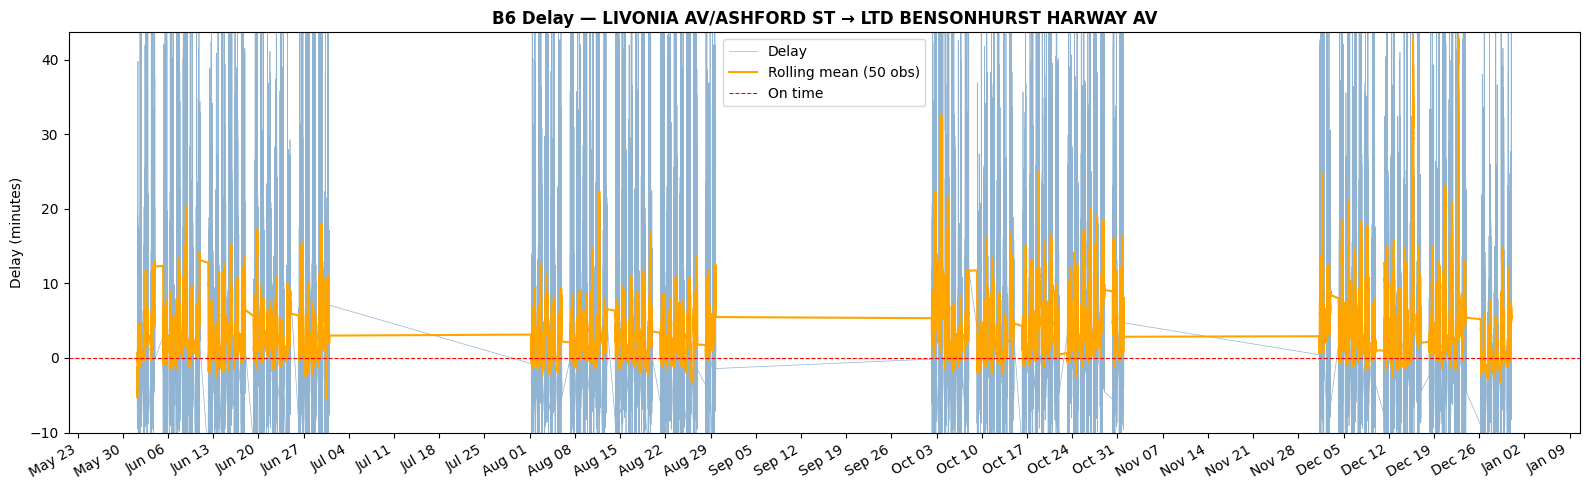

In [18]:
# Pick your OD pair
origin      = 'LIVONIA AV/ASHFORD ST'  
destination = 'LTD BENSONHURST HARWAY AV'

# Filter and sort chronologically
mask  = (df_B6['OriginName'] == origin) & (df_B6['DestinationName'] == destination)
group = df_B6[mask].sort_values('Scheduled_dt').copy()

# Plot
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(group['Scheduled_dt'], group['delay_minutes'],
        linewidth=0.5, alpha=0.6, color='steelblue', label='Delay')

# # OR safer: use positional rolling (e.g., 50 observations)
rolling = group['delay_minutes'].rolling(window=50, min_periods=1).mean()
ax.plot(group['Scheduled_dt'], rolling, color='orange', linewidth=1.5, label='Rolling mean (50 obs)')

ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='On time')
ax.set_title(f'B6 Delay — {origin} → {destination}', fontsize=12, fontweight='bold')
ax.set_ylabel('Delay (minutes)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
# Option 1 — Percentile-based (recommended)
lower = group['delay_minutes'].quantile(0.01)
upper = group['delay_minutes'].quantile(0.99)
ax.set_ylim(lower, upper)
ax.legend()

plt.tight_layout()
plt.savefig('B6_delay_timeseries_OD.png', dpi=150, bbox_inches='tight')
plt.show()